In [1]:
%load_ext autoreload
%autoreload 2

# B6 (partie 2) — Auto-encodeur & détection d'anomalies

Reprend les jeux prétraités en [partie 1](b6_deep_learning_donnees.md) (`screw/*.bin.gz`) pour concevoir,
entraîner et évaluer un auto-encodeur convolutionnel de détection d'anomalies.

In [2]:
import gzip
from pathlib import Path

import numpy as np

DATA_DIR = Path('screw')
IMG_SIZE = 128


def load_bin_gz(path, img_size=IMG_SIZE):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype='float32')
    return data.reshape(-1, img_size, img_size, 1)


X_train_norm = load_bin_gz(DATA_DIR / 'train_norm.bin.gz')
test_good_norm = load_bin_gz(DATA_DIR / 'test_good_norm.bin.gz')
test_defects_norm_stacked = load_bin_gz(DATA_DIR / 'test_defects_norm.bin.gz')

print('Train (normé)  :', X_train_norm.shape, X_train_norm.dtype)
print('Test saines    :', test_good_norm.shape)
print('Test défauts   :', test_defects_norm_stacked.shape)

Train (normé)  : (256, 128, 128, 1) float32
Test saines    : (41, 128, 128, 1)
Test défauts   : (119, 128, 128, 1)


Conception de l'auto-encodeur

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

INPUT_SHAPE = X_train_norm.shape[1:]  # (128, 128, 1)

inputs = keras.Input(shape=INPUT_SHAPE, name='image')

# Encodeur : 3 convolutions stridées, le nombre de filtres se resserre pour forcer un vrai goulot
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)  # 64x64x32
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)       # 32x32x64
latent = layers.Conv2D(16, 3, strides=2, padding='same', activation='relu')(x)  # 16x16x16 (goulot)

# Décodeur : 3 déconvolutions symétriques, sortie sigmoid dans [0, 1].
# Noyau=4 (multiple du stride=2) plutôt que 3, pour éviter l'artefact de damier
# ("checkerboard") typique des Conv2DTranspose quand noyau et stride ne s'accordent pas.
x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(latent)  # 32x32x64
x = layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu')(x)        # 64x64x32
outputs = layers.Conv2DTranspose(1, 4, strides=2, padding='same', activation='sigmoid')(x)  # 128x128x1

autoencoder = keras.Model(inputs, outputs, name='autoencodeur_screw')
autoencoder.summary()

Model: "autoencodeur_screw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │        16,448 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 1)    │           513 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,809 (303.94 KB)

 Trainable params: 77,809 (303.94 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
input_size = np.prod(INPUT_SHAPE)
latent_size = np.prod(latent.shape[1:])
ratio = latent_size / input_size

print(f'Taille entrée       : {input_size} valeurs {INPUT_SHAPE}')
print(f'Taille goulot       : {latent_size} valeurs {tuple(latent.shape[1:])}')
print(f'Ratio goulot/entrée : {ratio:.3f}  (compression ×{1 / ratio:.1f})')

Taille entrée       : 16384 valeurs (128, 128, 1)
Taille goulot       : 4096 valeurs (16, 16, 16)
Ratio goulot/entrée : 0.250  (compression ×4.0)


**Commentaire.** Le modèle compte **77 809 paramètres** (tous entraînables), essentiellement dans les
6 couches de convolution/déconvolution — pas de couche dense, donc pas d'explosion de paramètres malgré
la taille des images (128×128). Le décodeur utilise un noyau de taille **4** (multiple du stride 2, au lieu
de 3) pour éviter l'artefact de damier ("checkerboard") typique des `Conv2DTranspose`, ce qui explique le
léger surplus de paramètres par rapport à un noyau 3×3.

Le **goulot d'étranglement** est la sortie de la 3ᵉ convolution : `16×16×16 = 4096` valeurs, contre
`128×128×1 = 16384` valeurs en entrée → **ratio de 0.25** (compression ×4). Ce ratio est volontairement
resserré via le nombre de filtres (32 → 64 → **16**, et non croissant jusqu'au bout) : avec un goulot proche
de la taille d'entrée, le modèle pourrait apprendre une quasi-identité et reconstruire aussi bien les
défauts que les pièces saines, ce qui ferait disparaître le signal d'anomalie recherché.

*Mise à jour* : le goulot était initialement à 8 canaux (ratio 0.125, ×8). Élargi à 16 canaux (ratio 0.25,
×4) pour réduire le flou de reconstruction observé même sur des saines (bruit de fond qui noyait le signal
des petits défauts). Gain mesuré : AUROC 0.978 → 0.982, faux négatifs 20 → 16 (à seuil centile-95 constant)
— amélioration réelle mais modeste, cohérente avec l'hypothèse plutôt qu'un changement radical.

# Étape 2

Entrainement du model, on entraine (enregistrement via MLFlow) un model

In [5]:
import mlflow
import tensorflow as tf

mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('b6_deep_learning_autoencodeur_16_16_16')


def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


EPOCHS = 80 # 1 EPOCH => toutes les images sont passées et la backprop (rétropropagation) est passée
BATCH_SIZE = 16
PATIENCE = 4
MIN_DELTA = 1e-3

autoencoder.compile(optimizer='adam', loss=ssim_loss)

# Arrête l'entraînement si val_loss ne s'améliore plus d'au moins MIN_DELTA pendant PATIENCE époques.
# Sans min_delta, un nouveau record de +0.0001 compte comme une "amélioration" et remet le compteur
# à zéro indéfiniment (ce qu'on observe ici : val_loss grappille des micro-records en permanence).
# restore_best_weights ramène le modèle à l'époque où val_loss était la meilleure, pas la dernière.
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    restore_best_weights=True,
)

with mlflow.start_run(run_name='autoencoder_conv_screw_ssim'):
    mlflow.log_params({
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'optimizer': 'adam',
        'loss': 'ssim',
        'decoder_kernel_size': 4,
        'early_stopping_patience': PATIENCE,
        'early_stopping_min_delta': MIN_DELTA,
        'latent_shape': str(tuple(latent.shape[1:])),
        'compression_ratio': round(float(ratio), 4),
    })

    history = autoencoder.fit(
        X_train_norm, X_train_norm,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=2,
    )

    mlflow.log_param('stopped_epoch', early_stopping.stopped_epoch or len(history.history['loss']))
    for epoch, (loss, val_loss) in enumerate(zip(history.history['loss'], history.history['val_loss'])):
        mlflow.log_metrics({'loss': loss, 'val_loss': val_loss}, step=epoch)

2026/07/21 16:41:31 INFO mlflow.tracking.fluent: Experiment with name 'b6_deep_learning_autoencodeur_16_16_16' does not exist. Creating a new experiment.


Epoch 1/80


13/13 - 5s - 375ms/step - loss: 0.2908 - val_loss: 0.2794


Epoch 2/80


13/13 - 4s - 293ms/step - loss: 0.2512 - val_loss: 0.2324


...

13/13 - 7s - 500ms/step - loss: 0.0403 - val_loss: 0.0407


Epoch 49/80


13/13 - 7s - 538ms/step - loss: 0.0405 - val_loss: 0.0407


Epoch 50/80


13/13 - 7s - 507ms/step - loss: 0.0407 - val_loss: 0.0413


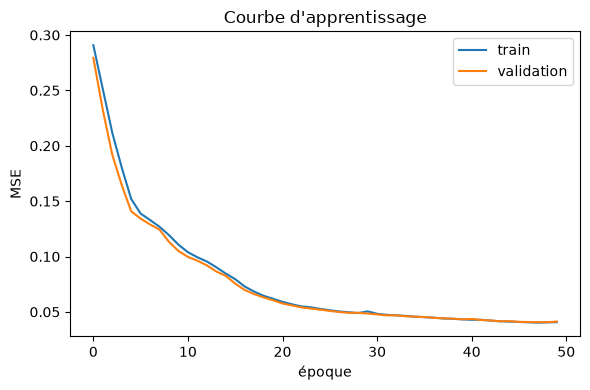

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('époque')
plt.ylabel('MSE')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.tight_layout()
plt.show()

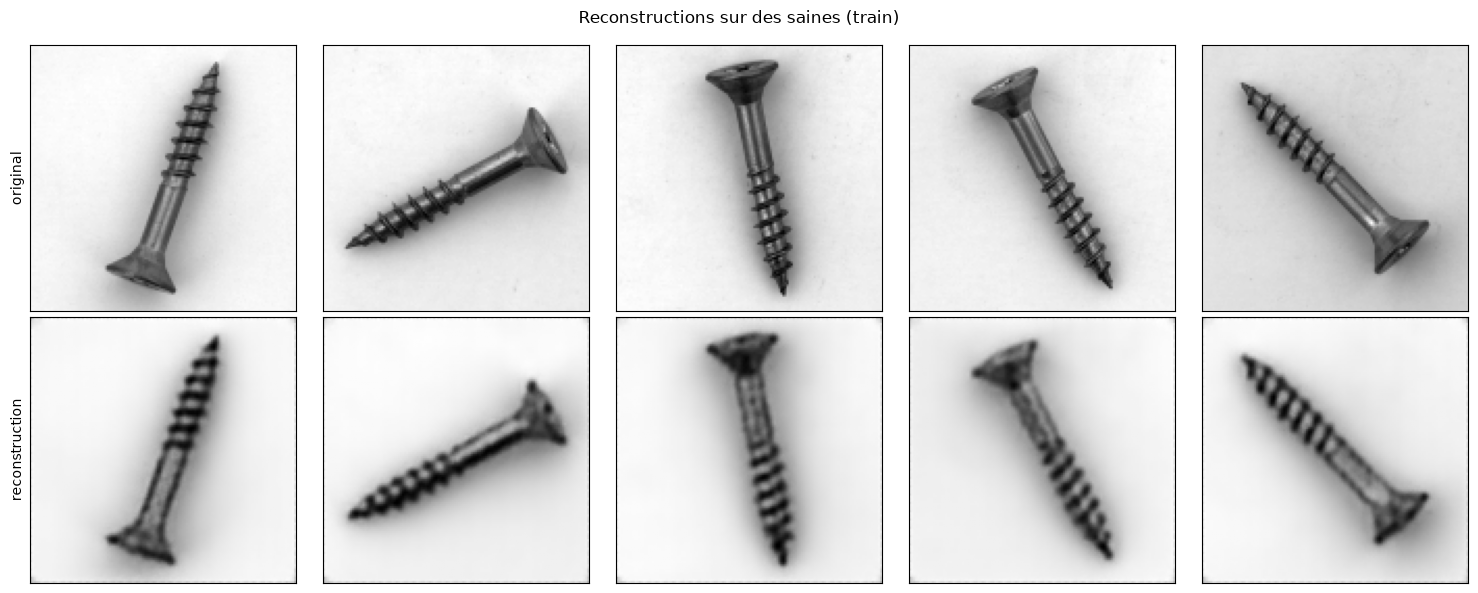

In [7]:
n_examples = 5
reconstructions = autoencoder.predict(X_train_norm[:n_examples], verbose=0)

fig, axes = plt.subplots(2, n_examples, figsize=(3 * n_examples, 6))
for i in range(n_examples):
    axes[0, i].imshow(X_train_norm[i, ..., 0], cmap='gray')
    axes[1, i].imshow(reconstructions[i, ..., 0], cmap='gray')

axes[0, 0].set_ylabel('original')
axes[1, 0].set_ylabel('reconstruction')
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Reconstructions sur des saines (train)')
fig.tight_layout()
plt.show()

# Étape 3 — Score d'anomalie & seuil

In [8]:
VALIDATION_SPLIT = 0.2  # doit correspondre au validation_split utilisé dans le fit()

# Keras prend les derniers `validation_split` % de X_train_norm comme validation (avant shuffle) :
# on retrouve ce même sous-ensemble pour évaluer l'erreur de reconstruction.
split_at = int(len(X_train_norm) * (1 - VALIDATION_SPLIT))
X_val_norm = X_train_norm[split_at:]


def reconstruction_score(images, reconstructions, percentile=99):
    """Score par image = centile 99 de l'erreur pixel (et non la moyenne).

    Un défaut n'occupe qu'une petite zone de l'image : sa contribution à une
    moyenne sur toute l'image est diluée par le bruit de reconstruction du
    filetage (présent même sur des saines). Le centile 99 capte le pic
    d'erreur local, plus discriminant qu'une moyenne globale.
    """
    squared_error = (images - reconstructions) ** 2
    return np.percentile(squared_error, percentile, axis=(1, 2, 3))


reconstructions_val = autoencoder.predict(X_val_norm, verbose=0)
errors_val = reconstruction_score(X_val_norm, reconstructions_val)

print('Erreur de reconstruction (saines, validation) :', errors_val.shape)
print(f'  moyenne = {errors_val.mean():.5f}, écart-type = {errors_val.std():.5f}')

Erreur de reconstruction (saines, validation) : (52,)
  moyenne = 0.00850, écart-type = 0.00156


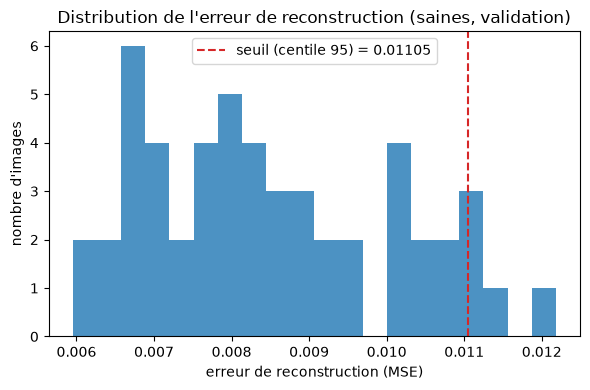

In [9]:
threshold_p95 = np.percentile(errors_val, 95)

plt.figure(figsize=(6, 4))
plt.hist(errors_val, bins=20, color='tab:blue', alpha=0.8)
plt.axvline(threshold_p95, color='tab:red', linestyle='--', label=f'seuil (centile 95) = {threshold_p95:.5f}')
plt.xlabel('erreur de reconstruction (MSE)')
plt.ylabel("nombre d'images")
plt.title("Distribution de l'erreur de reconstruction (saines, validation)")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
reconstructions_test_good = autoencoder.predict(test_good_norm, verbose=0)
errors_test_good = reconstruction_score(test_good_norm, reconstructions_test_good)

print('Erreur de reconstruction (saines, test) :', errors_test_good.shape)
print(f'  moyenne = {errors_test_good.mean():.5f}, écart-type = {errors_test_good.std():.5f}')

Erreur de reconstruction (saines, test) : (41,)
  moyenne = 0.00619, écart-type = 0.00087


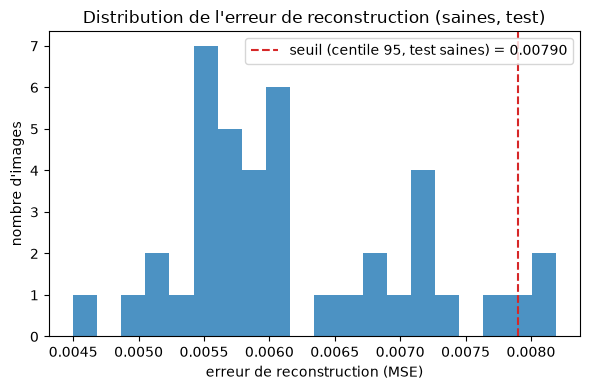

In [11]:
threshold_p95_test = np.percentile(errors_test_good, 95)

plt.figure(figsize=(6, 4))
plt.hist(errors_test_good, bins=20, color='tab:blue', alpha=0.8)
plt.axvline(threshold_p95_test, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95_test:.5f}')
plt.xlabel('erreur de reconstruction (MSE)')
plt.ylabel("nombre d'images")
plt.title("Distribution de l'erreur de reconstruction (saines, test)")
plt.legend()
plt.tight_layout()
plt.show()

Courbes saines de validation et de tests sensiblement identiques 

In [12]:
reconstructions_test_defects = autoencoder.predict(test_defects_norm_stacked, verbose=0)
errors_test_defects = reconstruction_score(test_defects_norm_stacked, reconstructions_test_defects)

print('Erreur de reconstruction (défauts, test) :', errors_test_defects.shape)
print(f'  moyenne = {errors_test_defects.mean():.5f}, écart-type = {errors_test_defects.std():.5f}')

Erreur de reconstruction (défauts, test) : (119,)
  moyenne = 0.00912, écart-type = 0.00109


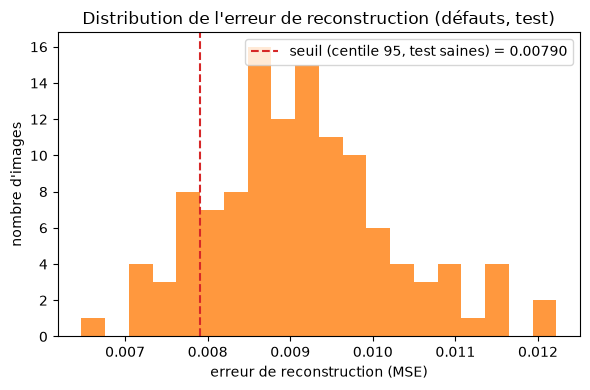

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(errors_test_defects, bins=20, color='tab:orange', alpha=0.8)
plt.axvline(threshold_p95_test, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95_test:.5f}')
plt.xlabel('erreur de reconstruction (MSE)')
plt.ylabel("nombre d'images")
plt.title("Distribution de l'erreur de reconstruction (défauts, test)")
plt.legend()
plt.tight_layout()
plt.show()

# Étape 4 — Heatmaps & évaluation

On prend trois images du set test_defects_norm_stacked et on affiche :
original | reconstruction | heatmap | masque ground-truth

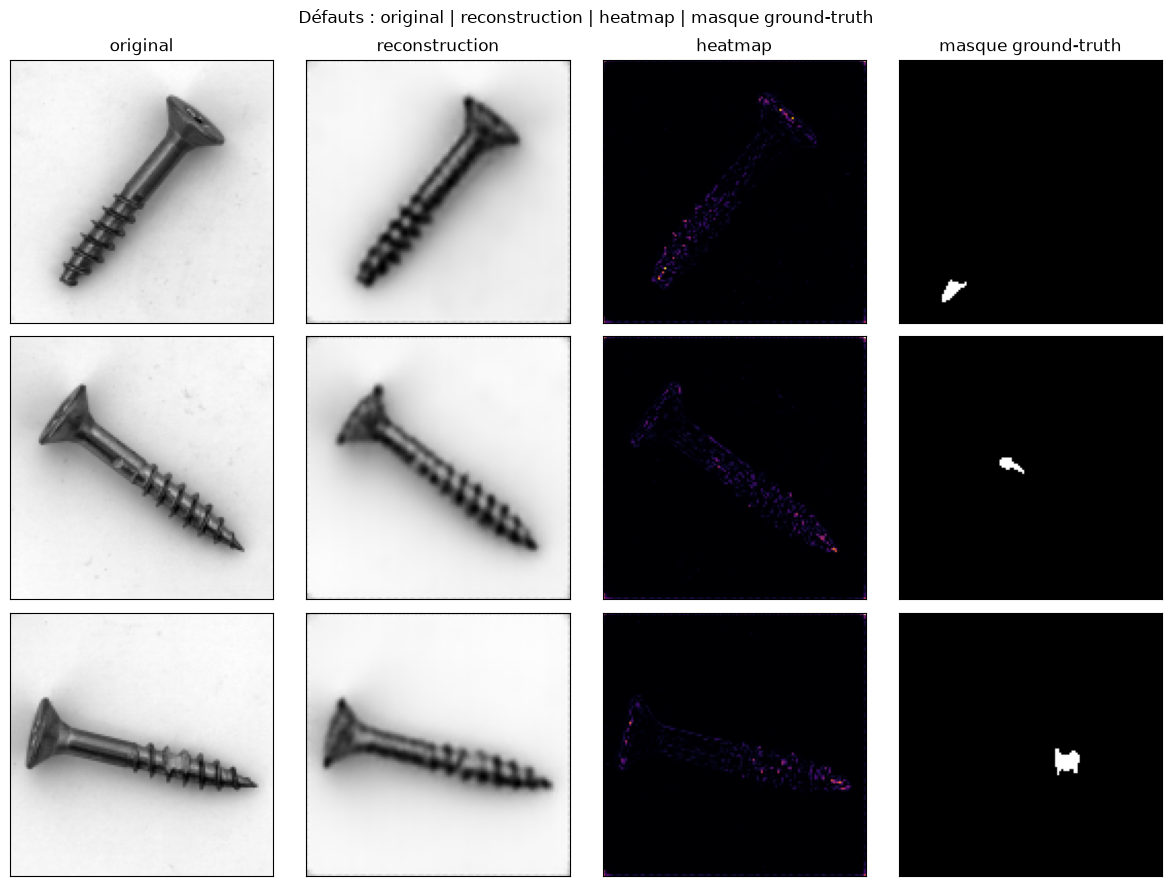

In [14]:
import cv2

TEST_DIR = DATA_DIR / 'test'
GT_DIR = DATA_DIR / 'ground_truth'
defect_types = sorted(p.name for p in TEST_DIR.iterdir() if p.is_dir() and p.name != 'good')

# Reconstitue, pour chaque indice de test_defects_norm_stacked, le chemin du masque correspondant
# (même ordre de concaténation qu'en partie 1 : catégories triées, fichiers triés dans chaque catégorie).
mask_paths = []
for defect in defect_types:
    img_paths = sorted((TEST_DIR / defect).glob('*.png'))
    mask_paths += [GT_DIR / defect / f'{p.stem}_mask.png' for p in img_paths]


def load_mask(path, size=IMG_SIZE):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)


indices = [0, 50, 100]  # trois défauts de catégories différentes (déjà en mémoire, pas de recalcul)

fig, axes = plt.subplots(len(indices), 4, figsize=(12, 3 * len(indices)))
col_titles = ['original', 'reconstruction', 'heatmap', 'masque ground-truth']

for row, idx in enumerate(indices):
    original = test_defects_norm_stacked[idx, ..., 0]
    reconstruction = reconstructions_test_defects[idx, ..., 0]
    heatmap = (original - reconstruction) ** 2
    mask = load_mask(mask_paths[idx])

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 1].imshow(reconstruction, cmap='gray')
    axes[row, 2].imshow(heatmap, cmap='inferno')
    axes[row, 3].imshow(mask, cmap='gray')

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Défauts : original | reconstruction | heatmap | masque ground-truth')
fig.tight_layout()
plt.show()

# Évalution AUC-ROC

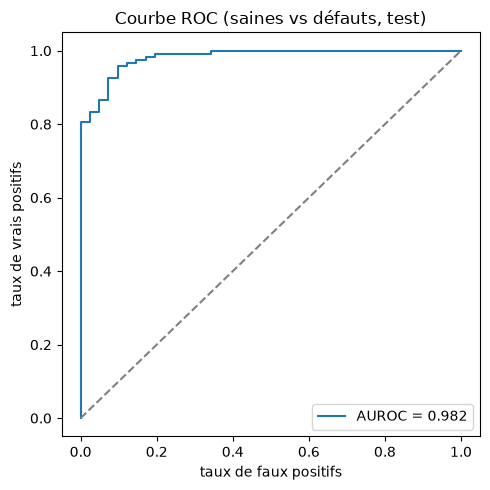

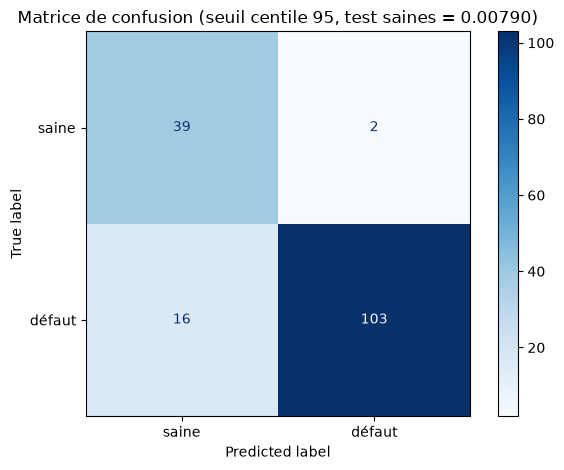

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, roc_curve

y_true = np.concatenate([np.zeros(len(errors_test_good)), np.ones(len(errors_test_defects))])
y_score = np.concatenate([errors_test_good, errors_test_defects])

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUROC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('taux de faux positifs')
plt.ylabel('taux de vrais positifs')
plt.title('Courbe ROC (saines vs défauts, test)')
plt.legend()
plt.tight_layout()
plt.show()

y_pred = (y_score > threshold_p95_test).astype(int)
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['saine', 'défaut']).plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil centile 95, test saines = {threshold_p95_test:.5f})')
plt.tight_layout()
plt.show()

### quel défaut est loupé ?

manipulated_front   : 7 loupé(s)
scratch_head        : 2 loupé(s)
scratch_neck        : 2 loupé(s)
thread_side         : 4 loupé(s)
thread_top          : 1 loupé(s)


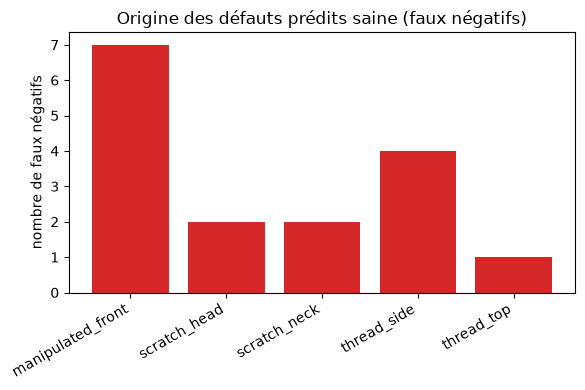

In [16]:
from collections import Counter

n_good = len(errors_test_good)
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0] - n_good  # défaut → saine, indices dans test_defects_norm_stacked

# mask_paths[i].parent.name = catégorie de défaut de l'image i (déjà construit plus haut)
missed_defect_types = [mask_paths[i].parent.name for i in fn_idx]
counts = Counter(missed_defect_types)

for defect in defect_types:
    print(f'{defect:<20}: {counts.get(defect, 0)} loupé(s)')

plt.figure(figsize=(6, 4))
plt.bar(defect_types, [counts.get(d, 0) for d in defect_types], color='tab:red')
plt.ylabel('nombre de faux négatifs')
plt.title('Origine des défauts prédits saine (faux négatifs)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

15 prédites saines alors qu'avec défaut (mais 104 défaut trouvés correctement)
2 prédites en défauts alors que saines (mais 39 saines trouvés correctement)

# Test visuel pour comprendre

On prend les deux faux-positifs en défaut (alors que saine), et deux faux-positifs prédites saines sur les 15 (alors qu'en défaut)


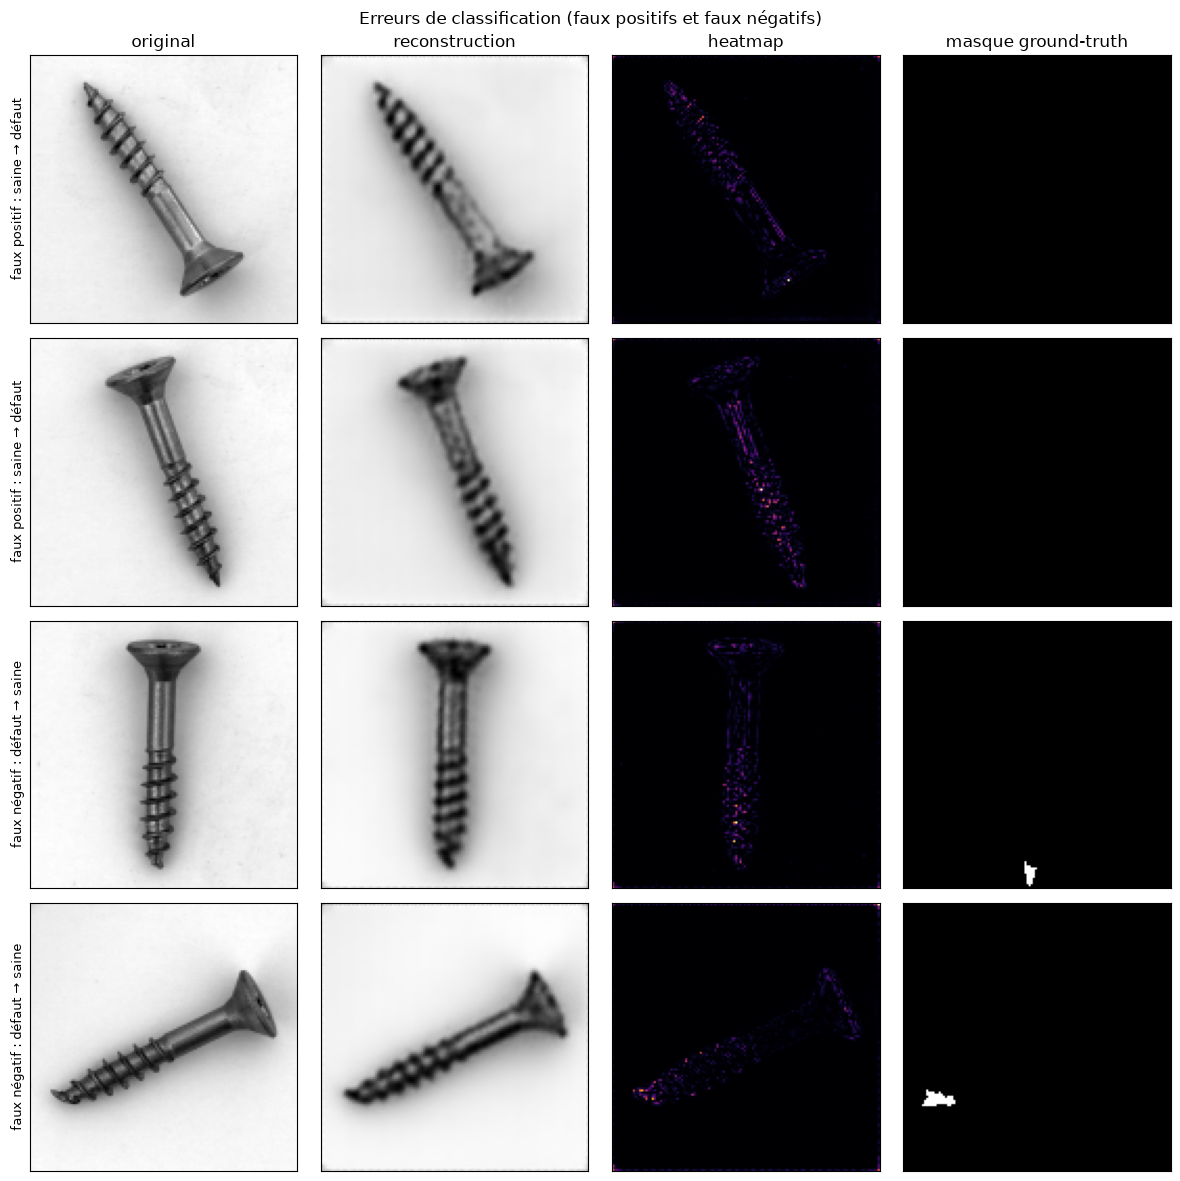

In [17]:
n_good = len(errors_test_good)  # offset : y_true/y_pred = [saines de test, puis défauts de test]

fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]          # saine → défaut, indices directs dans test_good_norm
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0] - n_good  # défaut → saine, indices dans test_defects_norm_stacked

selected_fp = fp_idx[:2]
selected_fn = fn_idx[:2]

# (étiquette, indice, images, reconstructions, chemins des masques ou None si pas de défaut à localiser)
rows = [('faux positif : saine → défaut', i, test_good_norm, reconstructions_test_good, None) for i in selected_fp]
rows += [('faux négatif : défaut → saine', i, test_defects_norm_stacked, reconstructions_test_defects, mask_paths) for i in selected_fn]

fig, axes = plt.subplots(len(rows), 4, figsize=(12, 3 * len(rows)))
col_titles = ['original', 'reconstruction', 'heatmap', 'masque ground-truth']

for row, (label, idx, images, reconstructions, masks) in enumerate(rows):
    original = images[idx, ..., 0]
    reconstruction = reconstructions[idx, ..., 0]
    heatmap = (original - reconstruction) ** 2
    mask = load_mask(masks[idx]) if masks is not None else np.zeros_like(original)

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 1].imshow(reconstruction, cmap='gray')
    axes[row, 2].imshow(heatmap, cmap='inferno')
    axes[row, 3].imshow(mask, cmap='gray')
    axes[row, 0].set_ylabel(label, fontsize=9)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Erreurs de classification (faux positifs et faux négatifs)')
fig.tight_layout()
plt.show()